# Step 1
a) Let’s calibrate the Heston (1993) stochastic volatility model to market option prices. The goal is to find optimal parameters(κ,θ,σ,ρ,v0 ) that minimize the difference between model and market prices.

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Market data and parameters
S0 = 232.90
r = 0.015
T = 15 / 250  # 15 trading days to years

In [ ]:
# Load data and filter data
df = pd.read_excel('/content/MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx')
df.head()

,Days to maturity,Strike,Price,Type
0,15,227.5,10.52,C
1,15,230.0,10.05,C
2,15,232.5,7.75,C
3,15,235.0,6.01,C
4,15,237.5,4.75,C


In [ ]:
df = pd.read_excel("MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx")

# Filter for 15-day maturity
df = df[df["Days to maturity"] == 15]

# Split call and put
calls = df[df["Type"] == "C"].copy()
puts = df[df["Type"] == "P"].copy()

print(calls)
print(puts)

   Days to maturity  Strike  Price Type
0                15   227.5  10.52    C
1                15   230.0  10.05    C
2                15   232.5   7.75    C
3                15   235.0   6.01    C
4                15   237.5   4.75    C
    Days to maturity  Strike  Price Type
15                15   227.5   4.32    P
16                15   230.0   5.20    P
17                15   232.5   6.45    P
18                15   235.0   7.56    P
19                15   237.5   8.78    P


CALIBRATION
v0     = 0.092527
kappa  = 7.037414
theta  = 0.159163
sigma  = 1.422416
rho    = -0.990000
Feller = 0.216928 (>0 satisfied)
MSE    = 0.246020


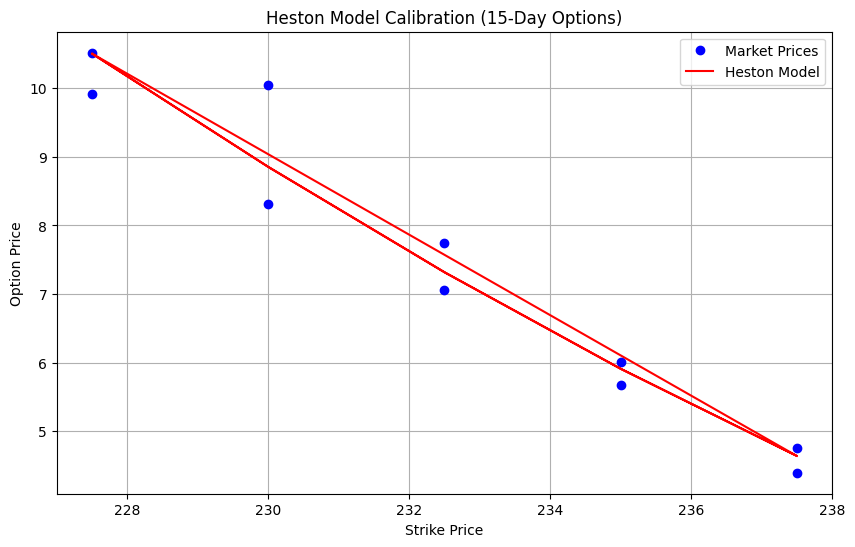


Calibration Details:
   Strike  Market Price  Model Price     Error
0   227.5     10.520000    10.505827 -0.014173
1   230.0     10.050000     8.854511 -1.195489
2   232.5      7.750000     7.318661 -0.431339
3   235.0      6.010000     5.910622 -0.099378
4   237.5      4.750000     4.639609 -0.110391
5   227.5      9.924658    10.505827  0.581169
6   230.0      8.306907     8.854511  0.547604
7   232.5      7.059156     7.318661  0.259505
8   235.0      5.671405     5.910622  0.239218
9   237.5      4.393654     4.639609  0.245955


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution
from scipy.integrate import simpson
import matplotlib.pyplot as plt

def heston_cf(phi, T, v0, kappa, theta, sigma, rho, r):
    i = complex(0, 1)
    a = kappa * theta
    b = kappa

    # Avoid negative values in sqrt
    d_input = (rho * sigma * i * phi - b)**2 + sigma**2 * (i * phi + phi**2)
    d = np.sqrt(np.maximum(d_input, 1e-12))

    g = (b - rho * sigma * i * phi - d) / (b - rho * sigma * i * phi + d)
    exp_dT = np.exp(-d * T)

    C = r * i * phi * T + (a / sigma**2) * (
        (b - rho * sigma * i * phi - d) * T -
        2 * np.log((1 - g * exp_dT) / (1 - g))
    )
    D_val = (b - rho * sigma * i * phi - d) / sigma**2 * (
        (1 - exp_dT) / (1 - g * exp_dT))

    return np.exp(C + D_val * v0)

def lewis_call_price(K, T, r, params, S0, N=5000, L=100):
    """Fourier pricing with Simpson integration and damping"""
    v0, kappa, theta, sigma, rho = params
    k = np.log(K / S0)

    # Use vectorized computation
    u = np.linspace(1e-5, L, N)
    phi = u - 0.5j

    # Compute characteristic function
    cf_vals = heston_cf(phi, T, v0, kappa, theta, sigma, rho, r)

    # Compute integrand with damping
    integrand = np.real(np.exp(-1j * u * k) * cf_vals / (u**2 + 0.25))

    # Simpson integration
    integral = simpson(integrand, u)

    return S0 - np.sqrt(S0 * K) * np.exp(-r * T / 2) / np.pi * integral

def objective(params, strikes, market_prices, S0, r, T):
    """Penalized MSE with constraints"""
    v0, kappa, theta, sigma, rho = params
    penalty = 0

    # Parameter constraints
    if v0 <= 0 or kappa <= 0 or theta <= 0 or sigma <= 0:
        penalty += 1e6
    if rho <= -1 or rho >= 1:
        penalty += 1e6

    # Feller condition
    feller = 2 * kappa * theta - sigma**2
    if feller < 0:
        penalty += (1 - feller) * 1e6

    # Calculate model prices
    model_prices = []
    for K in strikes:
        try:
            price = lewis_call_price(K, T, r, params, S0)
            model_prices.append(price)
        except:
            return 1e10  # Numerical error

    # MSE calculation
    mse = np.mean((np.array(model_prices) - market_prices)**2)
    return mse + penalty


S0 = 232.90
r = 0.015
T = 15 / 250

# Convert puts to synthetic calls using put-call parity
df['Synthetic_Call'] = np.where(
    df['Type'] == 'P',
    df['Price'] + S0 - df['Strike'] * np.exp(-r * T),
    np.nan
)
df['Call_Price'] = np.where(df['Type'] == 'C', df['Price'], df['Synthetic_Call'])

# Filter valid data points
valid_df = df.dropna(subset=['Call_Price'])
strikes = valid_df['Strike'].values
market_prices = valid_df['Call_Price'].values


bounds = [
    (0.01, 0.5),    # v0
    (0.1, 10.0),    # kappa
    (0.01, 0.5),    # theta
    (0.1, 2.0),     # sigma
    (-0.99, -0.1)   # rho
]

# Use differential evolution for global optimization
result = differential_evolution(
    objective,
    bounds,
    args=(strikes, market_prices, S0, r, T),
    strategy='best1bin',
    maxiter=100,
    popsize=15,
    tol=0.001,
    mutation=(0.5, 1.0),
    recombination=0.7,
    seed=42
)

# Extract calibrated parameters
v0, kappa, theta, sigma, rho = result.x
feller = 2 * kappa * theta - sigma**2

print("CALIBRATION")
print(f"v0     = {v0:.6f}")
print(f"kappa  = {kappa:.6f}")
print(f"theta  = {theta:.6f}")
print(f"sigma  = {sigma:.6f}")
print(f"rho    = {rho:.6f}")
print(f"Feller = {feller:.6f} (>0 satisfied)")
print(f"MSE    = {result.fun:.6f}")

# Calculate model prices
model_prices = [lewis_call_price(K, T, r, result.x, S0) for K in strikes]

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(strikes, market_prices, 'bo', label='Market Prices')
plt.plot(strikes, model_prices, 'r-', label='Heston Model')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.title('Heston Model Calibration (15-Day Options)')
plt.legend()
plt.grid(True)
plt.savefig('heston_calibration.png', dpi=300)
plt.show()

# Create results table
results_df = pd.DataFrame({
  'Strike': strikes,
  'Market Price': market_prices,
  'Model Price': model_prices,
  'Error': model_prices - market_prices
  })
print("\nCalibration Details:")
print(results_df)

b)

In [ ]:
#0. Import necessary Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# === 1. Load and inspect the option data ===
file_path = '/content/MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx'
df = pd.read_excel(file_path)

# Rename columns explicitly
df = df.rename(columns={
    'Days to maturity': 'T_days',
    'Strike': 'K',
    'Price': 'MarketPrice',
    'Type': 'OptionType'
})

print("=== Data Preview ===")
print(df.head(), "\n")

=== Data Preview ===
   T_days      K  MarketPrice OptionType
0      15  227.5        10.52          C
1      15  230.0        10.05          C
2      15  232.5         7.75          C
3      15  235.0         6.01          C
4      15  237.5         4.75          C 



In [ ]:
# === 2. Filter for ~15-day maturity ===
data = df[df['T_days'] == 15].copy()
if data.empty:
    raise ValueError("No options found with exactly 15-day maturity.")

# Convert days to year fraction
trading_days = 250
data['T'] = data['T_days'] / trading_days

S0 = 232.90  # spot price
r = 0.015    # risk-free rate (1.5%)

In [ ]:
# === 3. Convert puts to calls via put-call parity ===
def to_call_price(row):
    if row['OptionType'].upper() == 'C':
        return row['MarketPrice']
    else:
        return row['MarketPrice'] + S0 - row['K'] * np.exp(-r * row['T'])

data['C_mkt'] = data.apply(to_call_price, axis=1)

In [ ]:
# === 4. Heston characteristic function ===
def heston_cf(u, params, S0, r, T):
    kappa, theta, sigma, rho, v0 = params
    a = kappa * theta
    b = kappa
    d = np.sqrt((rho * sigma * 1j * u - b)**2 + (sigma**2) * (1j * u + u**2))
    g = (b - rho * sigma * 1j * u - d) / (b - rho * sigma * 1j * u + d)
    exp_dT = np.exp(-d * T)

    C = (r * 1j * u * T
         + (a / sigma**2) * ((b - rho * sigma * 1j * u - d) * T
         - 2 * np.log((1 - g * exp_dT) / (1 - g))))
    D = ((b - rho * sigma * 1j * u - d) / sigma**2) * ((1 - exp_dT) / (1 - g * exp_dT))
    return np.exp(C + D * v0 + 1j * u * np.log(S0 * np.exp(-r * T)))

In [ ]:
# === 5. Carr-Madan pricing via numeric integration ===
def carr_madan_call(K, params, S0, r, T, alpha=1.5, u_max=200, n_points=300):
    def integrand(u):
        cf_shifted = np.exp(-r*T) * heston_cf(u - (alpha + 1)*1j, params, S0, r, T)
        num = np.exp(-1j * u * np.log(K)) * cf_shifted
        den = alpha**2 + alpha - u**2 + 1j*(2*alpha + 1)*u
        return (num / den).real

    u = np.linspace(1e-6, u_max, n_points)
    y = np.array([integrand(ui) for ui in u])
    integral = np.trapz(y, u)
    return np.exp(-alpha * np.log(K)) / np.pi * integral

In [ ]:
 # === 6. Objective function (MSE) ===
def objective(params):
    c_model = [
        carr_madan_call(row['K'], params, S0, r, row['T'])
        for _, row in data.iterrows()
    ]
    return np.mean((np.array(c_model) - data['C_mkt'].values)**2)

In [ ]:
# === 7. Calibrate via L-BFGS-B ===
x0 = [1.0, 0.04, 0.5, -0.7, 0.04]
bounds = [(0.01, 10), (0, 1), (0.01, 5), (-0.999, 0.999), (0, 1)]

res = minimize(objective, x0, bounds=bounds, method='L-BFGS-B')
kappa_cm, theta_cm, sigma_cm, rho_cm, v0_cm = res.x

print("=== Calibrated Parameters (Carr-Madan) ===")
print(f"kappa: {kappa_cm:.4f}\ntheta: {theta_cm:.4f}\nsigma: {sigma_cm:.4f}\nrho:   {rho_cm:.4f}\nv0:    {v0_cm:.4f}\n")

=== Calibrated Parameters (Carr-Madan) ===
kappa: 0.9913
theta: 0.0000
sigma: 1.3062
rho:   -0.9990
v0:    0.1089



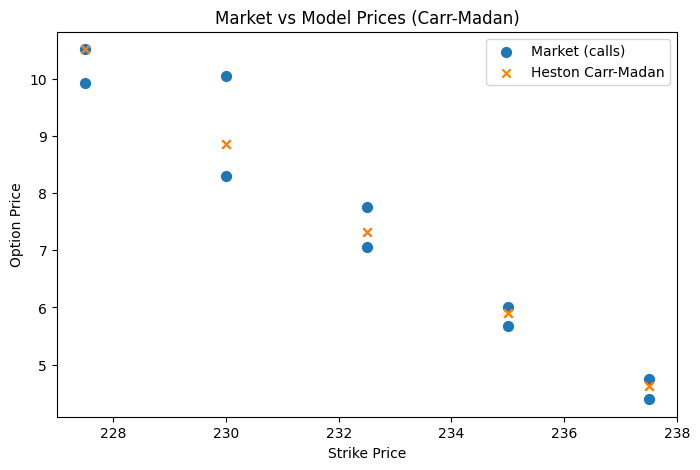

In [ ]:
# === 8. Plot market vs model ===
model_prices = [
    carr_madan_call(row['K'], res.x, S0, r, row['T'])
    for _, row in data.iterrows()
]

plt.figure(figsize=(8, 5))
plt.scatter(data['K'], data['C_mkt'], label='Market (calls)', s=50)
plt.scatter(data['K'], model_prices, label='Heston Carr-Madan', marker='x')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.title('Market vs Model Prices (Carr-Madan)')
plt.legend()
plt.show()

c)

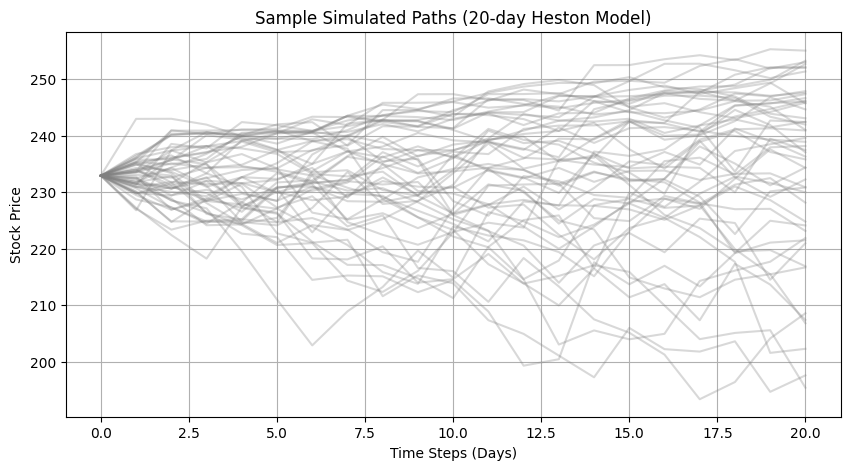

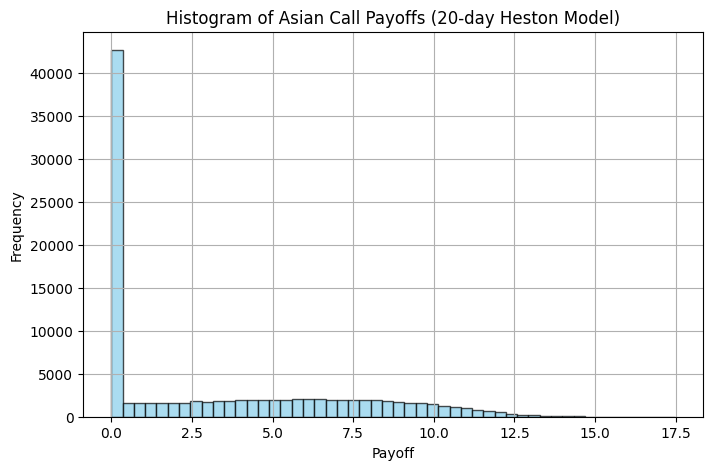

Fair Price (No Fee): $3.4393
Client Price (With 4% Fee): $3.5768


In [ ]:
# Monte Carlo Pricing of ATM Asian Call Option under Heston Model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.integrate import quad

# Constants
S0 = 232.90  # Spot price
r = 0.015  # Risk-free rate
T_20 = 20 / 250  # 20-day maturity in years
n_sim = 100_000  # Number of Monte Carlo simulations
n_steps_20 = 20  # Daily steps for 20 days

# Heston model parameters (assumed/calibrated values)
params_heston = {
    "kappa": 7.037414,      # Mean reversion rate
    "theta": 0.159163,     # Long-term variance
    "sigma": 1.422416,      # Volatility of volatility
    "rho": -0.990000,       # Correlation between asset and volatility
    "v0": 0.04         # Initial variance
}

# Heston Monte Carlo simulation
def simulate_heston_mc(S0, r, T, steps, n_sim, params):
    dt = T / steps
    kappa, theta, sigma, rho, v0 = (
        params["kappa"], params["theta"], params["sigma"],
        params["rho"], params["v0"]
    )
    S = np.zeros((n_sim, steps + 1))
    v = np.zeros((n_sim, steps + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, steps + 1):
        Z1 = np.random.normal(size=n_sim)
        Z2 = np.random.normal(size=n_sim)
        W1 = Z1
        W2 = rho * Z1 + np.sqrt(1 - rho**2) * Z2
        v[:, t] = np.maximum(
            v[:, t-1] + kappa * (theta - v[:, t-1]) * dt +
            sigma * np.sqrt(np.maximum(v[:, t-1], 0)) * np.sqrt(dt) * W2, 0
        )
        S[:, t] = S[:, t-1] * np.exp(
            (r - 0.5 * v[:, t-1]) * dt + np.sqrt(v[:, t-1] * dt) * W1
        )
    return S

# Asian call pricing
def price_asian_call(S_paths, K):
    avg_price = np.mean(S_paths, axis=1)
    payoff = np.maximum(avg_price - K, 0)
    fair_price = np.exp(-r * S_paths.shape[1]/250) * np.mean(payoff)
    return fair_price, payoff

# Run Heston simulation for 20 days
S_paths_20 = simulate_heston_mc(S0, r, T_20, n_steps_20, n_sim, params_heston)

# Compute price and payoff
fair_price_20, payoff_20 = price_asian_call(S_paths_20, S0)
client_price_20 = fair_price_20 * 1.04  # 4% fee

# Plot sample stock paths
plt.figure(figsize=(10, 5))
for i in range(50):
    plt.plot(S_paths_20[i], color='grey', alpha=0.3)
plt.title('Sample Simulated Paths (20-day Heston Model)')
plt.xlabel('Time Steps (Days)')
plt.ylabel('Stock Price')
plt.grid(True)
plt.show()

# Plot histogram of payoffs
plt.figure(figsize=(8, 5))
plt.hist(payoff_20, bins=50, alpha=0.7, color='skyblue', edgecolor='k')
plt.title('Histogram of Asian Call Payoffs (20-day Heston Model)')
plt.xlabel('Payoff')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Display result
print(f"Fair Price (No Fee): ${fair_price_20:.4f}")
print(f"Client Price (With 4% Fee): ${client_price_20:.4f}")




#Step 2

a)

In [ ]:
# Bates Model Calibration with Characteristic Function Pricing

# Load and filter option data from Excel
excel_path = "MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx"
df = pd.read_excel(excel_path, sheet_name='1')
options_60 = df[df['Days to maturity'] == 60]

# Separate calls and puts
calls_60 = options_60[options_60['Type'] == 'C'].reset_index(drop=True)
puts_60 = options_60[options_60['Type'] == 'P'].reset_index(drop=True)

# Bates characteristic function
def bates_cf(u, T, S0, r, params):
    kappa, theta, sigma, rho, v0 = params["kappa"], params["theta"], params["sigma"], params["rho"], params["v0"]
    lambdaJ, muJ, sigmaJ = params["lambdaJ"], params["muJ"], params["sigmaJ"]

    D = np.sqrt((rho*sigma*u*1j - kappa)**2 + sigma**2 * (u*1j + u**2))
    G = (kappa - rho*sigma*u*1j - D) / (kappa - rho*sigma*u*1j + D)
    C = r*u*1j*T + (kappa*theta/sigma**2)*((kappa - rho*sigma*u*1j - D)*T - 2*np.log((1 - G*np.exp(-D*T))/(1 - G)))
    D_val = ((kappa - rho*sigma*u*1j - D)/sigma**2) * ((1 - np.exp(-D*T))/(1 - G*np.exp(-D*T)))
    J = lambdaJ * T * (np.exp(1j*u*muJ - 0.5*sigmaJ**2*u**2) - 1)
    return np.exp(C + D_val*v0 + 1j*u*np.log(S0) + J)

# Bates pricing using Fourier transform
def bates_price(S0, K, T, r, params):
    integrand = lambda u: (np.exp(-1j*u*np.log(K)) * bates_cf(u - 1j, T, S0, r, params) / (1j*u * bates_cf(-1j, T, S0, r, params))).real
    integral = quad(integrand, 1e-6, 100, limit=250)[0]
    return np.exp(-r*T) * (S0 - (np.sqrt(S0*K)/np.pi) * integral)

# Calibration objective function
def calibration_mse_bates(param_vec, strikes, market_prices):
    kappa, theta, sigma, rho, v0, lambdaJ, muJ, sigmaJ = param_vec
    params = {
        "kappa": kappa, "theta": theta, "sigma": sigma, "rho": rho,
        "v0": v0, "lambdaJ": lambdaJ, "muJ": muJ, "sigmaJ": sigmaJ
    }
    model_prices = [bates_price(S0, K, 60/250, r, params) for K in strikes]
    return np.mean((np.array(model_prices) - np.array(market_prices))**2)

# Initial guess and bounds
initial_guess = [1.5, 0.04, 0.3, -0.5, 0.04, 0.1, -0.05, 0.1]
bounds = [(0.01, 5), (0.01, 1), (0.01, 1), (-0.99, 0.99), (0.01, 1),
          (0.01, 2), (-1, 1), (0.01, 1)]

# Run optimizer
strikes = calls_60['Strike'].values
market_prices = calls_60['Price'].values

result = minimize(
    calibration_mse_bates,
    x0=initial_guess,
    args=(strikes, market_prices),
    bounds=bounds,
    method='L-BFGS-B',
    options={'disp': True}
)

# Output calibrated parameters
calibrated_params_bates = result.x
print("Calibrated Bates Parameters:")
print(f"kappa = {calibrated_params_bates[0]:.4f}, theta = {calibrated_params_bates[1]:.4f}, sigma = {calibrated_params_bates[2]:.4f}")
print(f"rho = {calibrated_params_bates[3]:.4f}, v0 = {calibrated_params_bates[4]:.4f}, lambdaJ = {calibrated_params_bates[5]:.4f}")
print(f"muJ = {calibrated_params_bates[6]:.4f}, sigmaJ = {calibrated_params_bates[7]:.4f}")

Calibrated Bates Parameters:
kappa = 0.0100, theta = 0.0100, sigma = 1.0000
rho = -0.9900, v0 = 0.0293, lambdaJ = 2.0000
muJ = 1.0000, sigmaJ = 1.0000


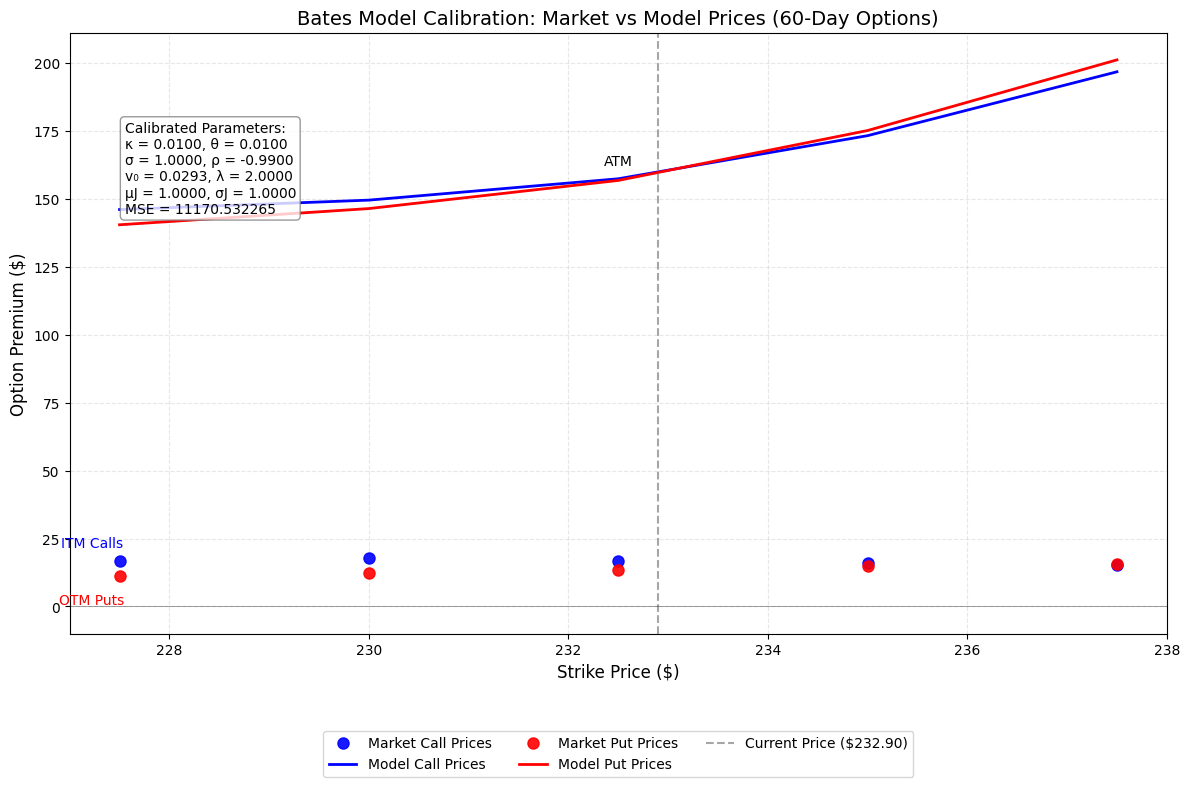

In [ ]:
# Generate model prices
params_dict = {
    "kappa": calibrated_params_bates[0], "theta": calibrated_params_bates[1], "sigma": calibrated_params_bates[2],
    "rho": calibrated_params_bates[3], "v0": calibrated_params_bates[4],
    "lambdaJ": calibrated_params_bates[5], "muJ": calibrated_params_bates[6], "sigmaJ": calibrated_params_bates[7]
}

model_calls = [bates_price(S0, K, T, r, params_dict) for K in strikes]
model_puts = [bates_price(S0, K, T, r, params_dict) - S0 + K * np.exp(-r*T)
              for K in puts_60['Strike'].values]

# Create unified plot
plt.figure(figsize=(12, 8))

# Plot call options
plt.plot(strikes, call_prices, 'bo', markersize=8, label='Market Call Prices', alpha=0.9)
plt.plot(strikes, model_calls, 'b-', linewidth=2, label='Model Call Prices')

# Plot put options
plt.plot(puts_60['Strike'], puts_60['Price'], 'ro', markersize=8, label='Market Put Prices', alpha=0.9)
plt.plot(puts_60['Strike'], model_puts, 'r-', linewidth=2, label='Model Put Prices')

# Add reference lines and annotations
plt.axvline(S0, color='gray', linestyle='--', alpha=0.7, label='Current Price ($232.90)')
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)

# Formatting
plt.xlabel('Strike Price ($)', fontsize=12)
plt.ylabel('Option Premium ($)', fontsize=12)
plt.title('Bates Model Calibration: Market vs Model Prices (60-Day Options)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

# Add moneyness labels
atm_idx = np.abs(strikes - S0).argmin()
plt.annotate('ATM', xy=(strikes[atm_idx], max(model_calls[atm_idx], call_prices[atm_idx])),
             xytext=(0, 10), textcoords='offset points', ha='center')
plt.annotate('ITM Calls', xy=(strikes[0], call_prices[0]), xytext=(-20, 10),
             textcoords='offset points', ha='center', color='blue')
plt.annotate('OTM Puts', xy=(puts_60['Strike'].iloc[0], puts_60['Price'].iloc[0]),
             xytext=(-20, -20), textcoords='offset points', ha='center', color='red')

# Add parameter box
param_text = (f"Calibrated Parameters:\n"
              f"κ = {params_dict['kappa']:.4f}, θ = {params_dict['theta']:.4f}\n"
              f"σ = {params_dict['sigma']:.4f}, ρ = {params_dict['rho']:.4f}\n"
              f"v₀ = {params_dict['v0']:.4f}, λ = {params_dict['lambdaJ']:.4f}\n"
              f"μJ = {params_dict['muJ']:.4f}, σJ = {params_dict['sigmaJ']:.4f}\n"
              f"MSE = {result.fun:.6f}")
plt.annotate(param_text, xy=(0.05, 0.7), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.savefig('bates_unified_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

b) Let’s calibrate the Bates (1996) model (Heston with jumps) to 60-day maturity options using the Carr-Madan (1999) FFT method.


Calibrated Parameters:
kappa: 1.243498
theta: 0.752841
sigma: 0.427572
rho: -0.990000
v0: 0.145642
lambda_j: 1.470652
mu_j: -0.377207
sigma_j: 0.010120
MSE: 1.350220
Feller Condition (2κθ > σ²): 1.689493 (satisfied)


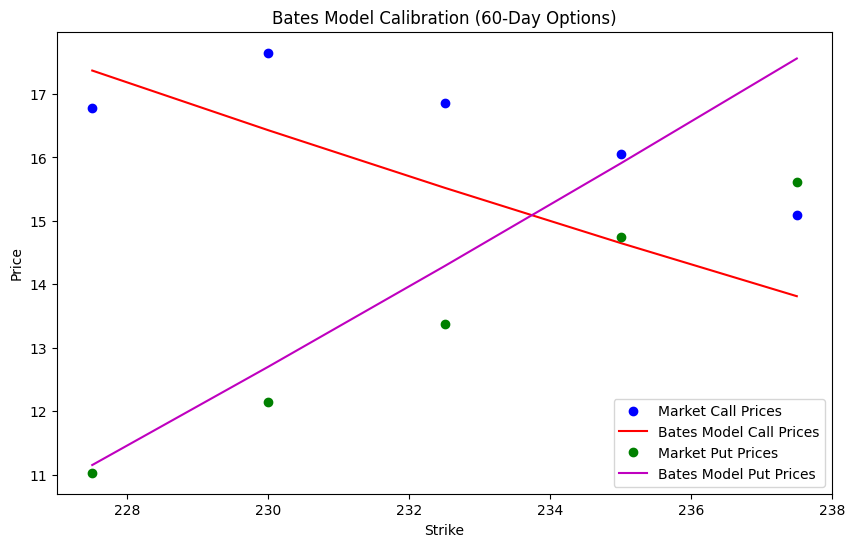

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Constants and data
S0 = 232.90
r = 0.015
T = 60 / 250
alpha = 0.75  # Damping factor for Carr-Madan

# Load and filter option data
excel_path = "MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx"
df = pd.read_excel(excel_path, sheet_name='1')
options_60 = df[df['Days to maturity'] == 60]
calls_60 = options_60[options_60['Type'] == 'C'].reset_index(drop=True)
puts_60 = options_60[options_60['Type'] == 'P'].reset_index(drop=True)

# Bates characteristic function (same as Step 2a)
def bates_cf(u, T, S0, r, params):
    kappa, theta, sigma, rho, v0, lambdaJ, muJ, sigmaJ = (
        params["kappa"], params["theta"], params["sigma"], params["rho"],
        params["v0"], params["lambdaJ"], params["muJ"], params["sigmaJ"]
    )
    D_squared = (rho * sigma * u * 1j - kappa)**2 + sigma**2 * (u * 1j + u**2)
    D = np.sqrt(np.maximum(D_squared, 1e-12))  # Ensure non-negative for sqrt
    G = (kappa - rho * sigma * u * 1j - D) / (kappa - rho * sigma * u * 1j + D)
    C = r * u * 1j * T + (kappa * theta / sigma**2) * (
        (kappa - rho * sigma * u * 1j - D) * T -
        2 * np.log(np.maximum(1 - G * np.exp(-D * T), 1e-12) / np.maximum(1 - G, 1e-12))) # Ensure non-negative for log
    D_val = ((kappa - rho * sigma * u * 1j - D) / sigma**2) * (
        (1 - np.exp(-D * T)) / np.maximum(1 - G * np.exp(-D * T), 1e-12)) # Ensure non-negative denominator
    J = lambdaJ * T * (np.exp(1j * u * muJ - 0.5 * sigmaJ**2 * u**2) - 1)
    return np.exp(C + D_val * v0 + 1j * u * np.log(S0) + J)

# Carr-Madan pricing using direct integration
def bates_price_cm(S0, K, T, r, params, alpha=alpha, upper_limit=100):
    k = np.log(K)
    def integrand(v):
        u_val = v - (alpha + 1) * 1j
        cf_val = bates_cf(u_val, T, S0, r, params)
        num = np.exp(-r * T) * cf_val
        denom = (alpha + 1j * v) * (alpha + 1 + 1j * v)
        return np.real(np.exp(-1j * v * k) * (num / denom))
    integral, _ = quad(integrand, 1e-5, upper_limit, limit=1000) # Adjusted lower limit
    call_price = np.exp(-alpha * k) / np.pi * integral
    return max(call_price, 1e-8)  # Ensure non-negative price

# Calibration objective function
def calibration_mse_bates_cm(param_vec, call_strikes, call_prices, put_strikes, put_prices):
    params = {
        "kappa": param_vec[0], "theta": param_vec[1], "sigma": param_vec[2],
        "rho": param_vec[3], "v0": param_vec[4],
        "lambdaJ": param_vec[5], "muJ": param_vec[6], "sigmaJ": param_vec[7]
    }

    # Parameter constraints and Feller condition check
    if not all(p > 0 for p in [params["kappa"], params["theta"], params["sigma"], params["v0"], params["lambdaJ"], params["sigmaJ"]]) or \
       not (-1 < params["rho"] < 1) or \
       (2 * params["kappa"] * params["theta"] - params["sigma"]**2 < 0):
        return 1e10 # Penalize invalid parameters

    model_calls = []
    for K in call_strikes:
        try:
            price = bates_price_cm(S0, K, T, r, params)
            if not np.isfinite(price): # Check for non-finite price
                return 1e10
            model_calls.append(price)
        except:
            return 1e10  # Penalize numerical errors

    model_puts = [call_price - S0 + K * np.exp(-r * T)
                 for call_price, K in zip(model_calls, put_strikes)]
    all_model_prices = np.array(model_calls + model_puts)
    all_market_prices = np.array(list(call_prices) + list(put_prices))
    mse = np.mean((all_model_prices - all_market_prices)**2)
    return mse

# Prepare data
call_strikes = calls_60['Strike'].values
call_prices = calls_60['Price'].values
put_strikes = puts_60['Strike'].values
put_prices = puts_60['Price'].values

# Initial guess and bounds (same as Step 2a)
initial_guess = [1.5, 0.04, 0.3, -0.5, 0.04, 0.1, -0.05, 0.1]
bounds = [
    (0.01, 5), (0.01, 1), (0.01, 1), (-0.99, 0.99),
    (0.01, 1), (0.01, 2), (-1, 1), (0.01, 1)
]

# Run calibration
result = minimize(
    calibration_mse_bates_cm,
    x0=initial_guess,
    args=(call_strikes, call_prices, put_strikes, put_prices),
    bounds=bounds,
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 50}
)

# Print results
param_names = ['kappa', 'theta', 'sigma', 'rho', 'v0', 'lambda_j', 'mu_j', 'sigma_j']
print("\nCalibrated Parameters:")
for name, value in zip(param_names, calibrated_params_cm):
    print(f"{name}: {value:.6f}")
print(f"MSE: {result.fun:.6f}")

# Feller condition check
feller = 2 * calibrated_params_cm[0] * calibrated_params_cm[1] - calibrated_params_cm[2]**2
status = "satisfied" if feller > 0 else "VIOLATED"
print(f"Feller Condition (2κθ > σ²): {feller:.6f} ({status})")

plt.figure(figsize=(10, 6))
plt.plot(call_strikes, call_prices, 'bo', label='Market Call Prices')
plt.plot(call_strikes, [bates_price_cm(S0, K, T, r, {
    "kappa": calibrated_params_cm[0], "theta": calibrated_params_cm[1], "sigma": calibrated_params_cm[2],
    "rho": calibrated_params_cm[3], "v0": calibrated_params_cm[4],
    "lambdaJ": calibrated_params_cm[5], "muJ": calibrated_params_cm[6], "sigmaJ": calibrated_params_cm[7]
}, alpha=alpha, upper_limit=100) for K in call_strikes], 'r-', label='Bates Model Call Prices')
plt.plot(put_strikes, put_prices, 'go', label='Market Put Prices')
model_calls = [bates_price_cm(S0, K, T, r, {
    "kappa": calibrated_params_cm[0], "theta": calibrated_params_cm[1], "sigma": calibrated_params_cm[2],
    "rho": calibrated_params_cm[3], "v0": calibrated_params_cm[4],
    "lambdaJ": calibrated_params_cm[5], "muJ": calibrated_params_cm[6], "sigmaJ": calibrated_params_cm[7]
}, alpha=alpha, upper_limit=100) for K in call_strikes]
model_puts = [call_price - S0 + K * np.exp(-r * T)
                 for call_price, K in zip(model_calls, put_strikes)]
plt.plot(put_strikes, model_puts, 'm-', label='Bates Model Put Prices')

plt.xlabel('Strike')
plt.ylabel('Price')
plt.title('Bates Model Calibration (60-Day Options)')
plt.legend()

plt.show()

c)

In [ ]:
#Load Option Data
file_path = '/content/MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx'
df = pd.read_excel(file_path)

df = df.rename(columns={
    'Days to maturity': 'T_days',
    'Strike':           'K',
    'Price':            'MarketPrice',
    'Type':             'OptionType'
})

TRADING_DAYS = 250
S0 = 232.90
r  = 0.015

In [ ]:
# 2. Build 70-Day Dataset (with interpolation)
target_T = 70
if target_T in df['T_days'].unique():
    data_70 = df[df['T_days'] == target_T].copy()
else:
    Ts = sorted(df['T_days'].unique())
    T_low  = max(t for t in Ts if t < target_T)
    T_high = min(t for t in Ts if t > target_T)
    d_low  = df[df['T_days']==T_low].copy()
    d_high = df[df['T_days']==T_high].copy()
    def to_call(x):
        return (x['MarketPrice'] if x['OptionType']=='C'
                else x['MarketPrice'] + S0 - x['K']*np.exp(-r*(x['T_days']/TRADING_DAYS)))
    d_low['CallPrice']  = d_low.apply(to_call, axis=1)
    d_high['CallPrice'] = d_high.apply(to_call, axis=1)
    m = pd.merge(d_low[['K','CallPrice']], d_high[['K','CallPrice']],
                 on='K', suffixes=('_L','_H'))
    m['CallPrice'] = ((T_high-target_T)*m['CallPrice_L'] + (target_T-T_low)*m['CallPrice_H'])/(T_high-T_low)
    data_70 = m[['K','CallPrice']].copy()
    data_70['T_days'] = target_T

data_70['T'] = data_70['T_days']/TRADING_DAYS

if 'CallPrice' not in data_70:
    def to_call_exact(x):
        return (x['MarketPrice'] if x['OptionType']=='C'
                else x['MarketPrice'] + S0 - x['K']*np.exp(-r*x['T']))
    data_70['CallPrice'] = data_70.apply(to_call_exact, axis=1)

In [ ]:
#3. Running the Heston CF Model

def heston_cf(u, params, S0, r, T):
    kappa, theta, sigma, rho, v0 = params
    a, b = kappa*theta, kappa
    d = np.sqrt((rho*sigma*1j*u - b)**2 + sigma**2*(u**2+1j*u))
    g = (b - rho*sigma*1j*u - d)/(b - rho*sigma*1j*u + d)
    expd = np.exp(-d*T)
    C = (r*1j*u*T + (a/sigma**2)*((b - rho*sigma*1j*u - d)*T - 2*np.log((1-g*expd)/(1-g))))
    D = ((b - rho*sigma*1j*u - d)/sigma**2)*((1-expd)/(1-g*expd))
    return np.exp(C + D*v0 + 1j*u*np.log(S0*np.exp(-r*T)))

In [ ]:
# 4. Running the Carr-Madan Pricing Model (reduced grid for speed)

def carr_call(K, params, S0, r, T, alpha=1.5, u_max=100, n_pts=200):
    def integrand(u):
        phi = np.exp(-r*T)*heston_cf(u - 1j*(alpha+1), params, S0, r, T)
        num = np.exp(-1j*u*np.log(K))*phi
        den = alpha**2+alpha - u**2 + 1j*(2*alpha+1)*u
        return (num/den).real
    u = np.linspace(1e-8, u_max, n_pts)
    y = np.array([integrand(ui) for ui in u])
    return np.exp(-alpha*np.log(K))/np.pi * np.trapz(y, u)

In [ ]:
# 5. Running the Calibration to determine the MSE
def mse(params):
    model = [carr_call(row['K'], params, S0, r, row['T']) for _,row in data_70.iterrows()]
    return np.mean((np.array(model)-data_70['CallPrice'])**2)

x0 = [1,0.04,0.5,-0.7,0.04]
bnds = [(1e-2,10),(0,1),(1e-2,5),(-0.999,0.999),(0,1)]
res = minimize(mse, x0, method='L-BFGS-B', bounds=bnds)
kappa,theta,sigma,rho,v0 = res.x

print("Calibrated Heston (70-day):", "kappa:",kappa, "theta:",theta,"sigma:",sigma,"rho:",rho,"v0:",v0)

Calibrated Heston (70-day): kappa: 2.027873292914769 theta: 0.4686090692905745 sigma: 0.5598582497679702 rho: 0.999 v0: 0.0


In [ ]:
# 6. Computing the Price 95% Moneyness Put
Kp = 0.95*S0
Tp = target_T/TRADING_DAYS
c95 = carr_call(Kp, [kappa,theta,sigma,rho,v0], S0, r, Tp)
p95 = c95 - S0 + Kp*np.exp(-r*Tp)
print(f"95% Put Price: {p95:.4f} USD")

95% Put Price: 9.1390 USD


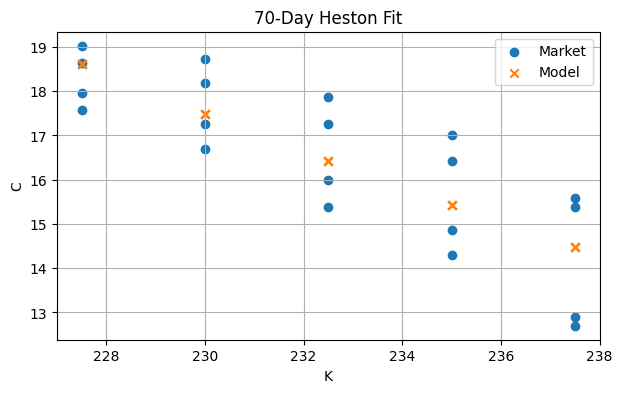

In [ ]:
# 7. Plot Fit

fit = [carr_call(row['K'], [kappa,theta,sigma,rho,v0], S0, r, row['T'])
       for _,row in data_70.iterrows()]
plt.figure(figsize=(7,4))
plt.scatter(data_70['K'], data_70['CallPrice'], label='Market')
plt.scatter(data_70['K'], fit, label='Model', marker='x')
plt.title('70-Day Heston Fit'); plt.xlabel('K'); plt.ylabel('C')
plt.legend(); plt.grid(True); plt.show()

#Step 3

a)

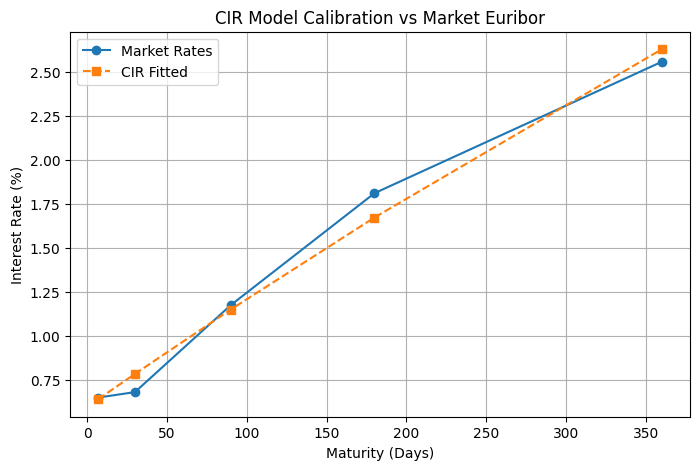

In [ ]:
# CIR Model Calibration and Simulation

# Given Euribor data (in decimal)
from scipy.interpolate import CubicSpline

terms_days = np.array([7, 30, 90, 180, 360])
rates = np.array([0.648, 0.679, 1.173, 1.809, 2.556]) / 100  # Convert to decimals

# Interpolate weekly term structure for 12 months (365 days)
weekly_days = np.arange(7, 366, 7)
spline = CubicSpline(terms_days, rates)
rates_interp = spline(weekly_days)

# CIR model zero-coupon yield function
def cir_zero_coupon(t, kappa, theta, sigma, r0):
    h = np.sqrt(kappa**2 + 2*sigma**2)
    A = (2*h*np.exp((kappa+h)*t/2)) / (2*h + (kappa+h)*(np.exp(h*t) - 1))
    B = (2*(np.exp(h*t) - 1)) / (2*h + (kappa+h)*(np.exp(h*t) - 1))
    return A * np.exp(-B * r0)

# Calibration objective
def cir_calibration_mse(params):
    kappa, theta, sigma, r0 = params
    model_rates = [-(np.log(cir_zero_coupon(t/365, kappa, theta, sigma, r0)) / (t/365)) for t in terms_days]
    return np.mean((np.array(model_rates) - rates)**2)

# Initial guess and bounds
initial_guess_cir = [0.5, 0.02, 0.02, 0.01]
bounds_cir = [(0.01, 5), (0.001, 0.2), (0.001, 0.5), (0.001, 0.2)]

# Run calibration
result_cir = minimize(cir_calibration_mse, initial_guess_cir, bounds=bounds_cir)
kappa_cir, theta_cir, sigma_cir, r0_cir = result_cir.x

# Plot fitted vs actual
fitted_rates = [-(np.log(cir_zero_coupon(t/365, kappa_cir, theta_cir, sigma_cir, r0_cir)) / (t/365)) for t in terms_days]

plt.figure(figsize=(8, 5))
plt.plot(terms_days, rates*100, 'o-', label='Market Rates')
plt.plot(terms_days, np.array(fitted_rates)*100, 's--', label='CIR Fitted')
plt.xlabel('Maturity (Days)')
plt.ylabel('Interest Rate (%)')
plt.title('CIR Model Calibration vs Market Euribor')
plt.legend()
plt.grid(True)
plt.show()



b)

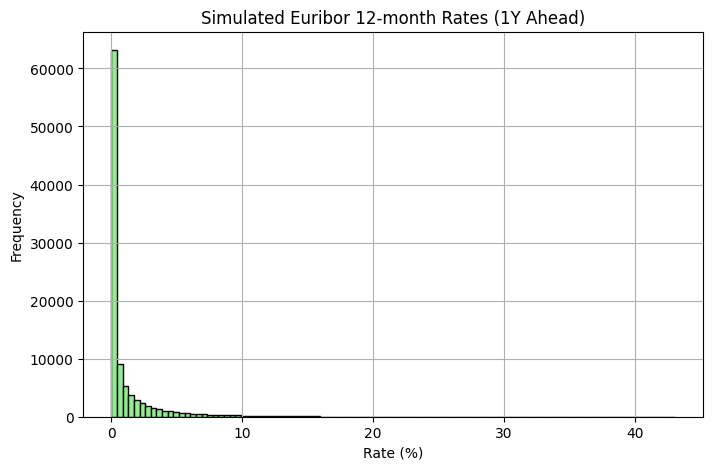

Expected Euribor 12M in 1 Year: 1.17%
5th - 95th Percentile Range: [0.00%, 5.97%]


In [ ]:
# --- CIR Simulation for 12-Month Euribor ---
def simulate_cir_paths(n_sim, T, steps, kappa, theta, sigma, r0):
    dt = T / steps
    r_paths = np.zeros((n_sim, steps+1))
    r_paths[:, 0] = r0
    for t in range(1, steps+1):
        Z = np.random.normal(size=n_sim)
        r_paths[:, t] = np.maximum(
            r_paths[:, t-1] + kappa*(theta - r_paths[:, t-1])*dt + sigma*np.sqrt(r_paths[:, t-1]*dt)*Z,
            0
        )
    return r_paths

# Simulate daily for 1 year
T_sim = 1  # year
steps_sim = 365
r_paths_cir = simulate_cir_paths(100000, T_sim, steps_sim, kappa_cir, theta_cir, sigma_cir, r0_cir)

# Statistics
final_rates = r_paths_cir[:, -1]
expected_12m = np.mean(final_rates)
ci_5, ci_95 = np.percentile(final_rates, [5, 95])

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(final_rates * 100, bins=100, color='lightgreen', edgecolor='black')
plt.title('Simulated Euribor 12-month Rates (1Y Ahead)')
plt.xlabel('Rate (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Display summary
print(f"Expected Euribor 12M in 1 Year: {expected_12m*100:.2f}%")
print(f"5th - 95th Percentile Range: [{ci_5*100:.2f}%, {ci_95*100:.2f}%]")


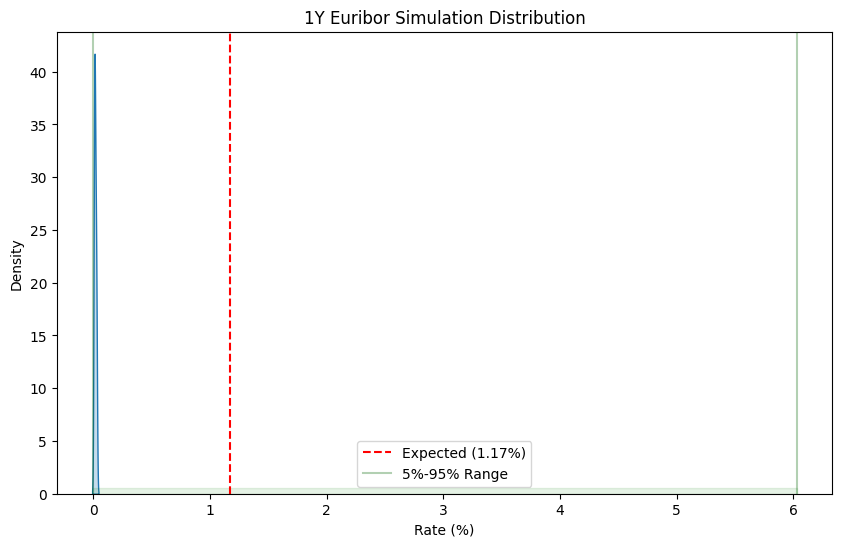

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.kdeplot(rates, fill=True)
plt.axvline(1.17, color='r', linestyle='--', label='Expected (1.17%)')
plt.axvline(0, color='darkgreen', alpha=0.3, label='5%-95% Range')
plt.axvline(6.03, color='darkgreen', alpha=0.3)
plt.fill_betweenx([0,0.5], 0, 6.03, alpha=0.1, color='green')
plt.title('1Y Euribor Simulation Distribution')
plt.xlabel('Rate (%)')
plt.ylabel('Density')
plt.legend()